# 🧠 AI Research Assistant — Phase 2: QLoRA Fine-Tuning
## Fine-Tuning LLaMA-3 on Academic QA Dataset with QLoRA + W&B Monitoring

---

**📋 What This Notebook Does:**
1. Installs and configures all required libraries
2. Mounts Google Drive for model saving
3. Loads and validates the `academic_qa.json` dataset
4. Applies QLoRA (4-bit quantization + LoRA adapters) to LLaMA-3-8B
5. Fine-tunes with full monitoring via Weights & Biases
6. Visualises training loss, validation loss, and learning rate curves
7. Evaluates with perplexity and sample generations
8. Saves and downloads the adapter to `models/finetuned/llama_adapter/`

**⚙️ Runtime Required:** GPU (A100 recommended, T4 works for demo)
> Runtime → Change runtime type → GPU → A100 or T4

---

## ✅ Step 0 — Verify GPU & CUDA Environment

**Why this matters:** QLoRA requires a CUDA-enabled GPU. We check GPU memory to
determine the maximum batch size and whether gradient checkpointing is needed.
A100 (40/80GB) → batch_size=4; T4 (16GB) → batch_size=1 with gradient checkpointing.

In [1]:
import subprocess, os

# Check GPU info
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free',
                         '--format=csv,noheader,nounits'], capture_output=True, text=True)
print("🖥️  GPU Info:")
print(result.stdout)

# Check CUDA
import torch
print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ CUDA version    : {torch.version.cuda}")
    print(f"✅ GPU name        : {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU memory      : {mem_gb:.1f} GB")
    if mem_gb >= 38:
        print("🚀 A100 detected — using batch_size=4")
    elif mem_gb >= 14:
        print("⚠️  T4/V100 detected — using batch_size=1 + gradient checkpointing")
    else:
        print("❌ Insufficient GPU memory for LLaMA-3-8B. Use Google Colab Pro+.")

🖥️  GPU Info:
Tesla T4, 15360, 14913

✅ PyTorch version : 2.10.0+cu128
✅ CUDA available  : True
✅ CUDA version    : 12.8
✅ GPU name        : Tesla T4
✅ GPU memory      : 15.6 GB
⚠️  T4/V100 detected — using batch_size=1 + gradient checkpointing


## 📦 Step 1 — Install Dependencies

**Why each package:**
- `transformers` — Load LLaMA-3 base model and tokenizer
- `peft` — LoRA adapter implementation (Low-Rank Adaptation)
- `bitsandbytes` — 4-bit quantization (NF4) enabling QLoRA
- `trl` — SFTTrainer for supervised fine-tuning with loss masking
- `accelerate` — Multi-GPU and mixed-precision training utilities
- `wandb` — Weights & Biases experiment tracking and visualisation
- `datasets` — HuggingFace dataset loading and processing

> ⏱️ Installation takes ~3 minutes on first run. Subsequent runs are faster (cached).

In [1]:
!pip uninstall -y bitsandbytes peft triton -q

In [2]:
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.


In [3]:
pip install -U transformers accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 131.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.29.3
    Uninstalling accelerate-0.29.3:
      Successfully uninstalled accelerate-0.29.3
  Attempting uninstall: transformers
    Found existing installatio

In [ ]:
%%capture
!pip install -U "numpy<2.0"
!pip install -U transformers trl accelerate datasets wandb scipy
!pip install -U bitsandbytes peft

import os
# Restart kernel to apply library updates
os.kill(os.getpid(), 9)

In [2]:
#print numpy versiion
import numpy as np
print(np.__version__)

1.26.4


## 💾 Step 2 — Mount Google Drive & Set Configuration

**Why Drive?** Colab's ephemeral filesystem loses all data when the session ends.
Mounting Drive ensures the trained adapter, checkpoints, and logs are persisted.

**Configuration Guide:**
| Parameter | Value | Rationale |
|---|---|---|
| `MODEL_NAME` | `meta-llama/Meta-Llama-3-8B` | Best open base model at 8B scale |
| `LORA_R` | 16 | Rank — higher = more expressive but more params |
| `LORA_ALPHA` | 32 | Scale = alpha/r = 2.0 (standard) |
| `MAX_SEQ_LEN` | 1024 | Covers our academic QA length |
| `BATCH_SIZE` | 2 | Per-device, adjust based on GPU |
| `EPOCHS` | 3 | Enough for convergence on 30+ examples |
| `LR` | 2e-4 | Standard LoRA learning rate |

In [2]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# ─── Create output directories ────────────────────────────────────────────────
# Note: On some systems, creating nested dirs on /content/drive requires careful handling
BASE_DIR    = '/content/drive/MyDrive/ai_research_assistant'
MODEL_DIR   = f'{BASE_DIR}/models/finetuned/llama_adapter'
DATASET_DIR = f'{BASE_DIR}/data/datasets'
LOG_DIR     = f'{BASE_DIR}/logs'

# Create path one by one to avoid Errno 95
try:
    if not os.path.exists(BASE_DIR):
        os.makedirs(BASE_DIR, exist_ok=True)
    for d in [MODEL_DIR, DATASET_DIR, LOG_DIR]:
        os.makedirs(d, exist_ok=True)
    print("✅ Google Drive mounted and directories ready")
except Exception as e:
    print(f"⚠️ Warning: Directory creation failed with {e}")
    print("Switching to local /content/ storage to prevent block.")
    BASE_DIR = '/content/ai_research_assistant'
    MODEL_DIR, DATASET_DIR, LOG_DIR = f'{BASE_DIR}/models', f'{BASE_DIR}/data', f'{BASE_DIR}/logs'
    for d in [MODEL_DIR, DATASET_DIR, LOG_DIR]: os.makedirs(d, exist_ok=True)

# ─── Core Configuration ───────────────────────────────────────────────────────
import torch

CONFIG = {
    "MODEL_NAME"        : "mistralai/Mistral-7B-v0.1",
    "USE_4BIT"          : True,
    "BNB_4BIT_COMPUTE"  : "bfloat16",
    "BNB_QUANT_TYPE"    : "nf4",
    "LORA_R"            : 16,
    "LORA_ALPHA"        : 32,
    "LORA_DROPOUT"      : 0.05,
    "TARGET_MODULES"    : ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "MAX_SEQ_LEN"       : 1024,
    "BATCH_SIZE"        : 2,
    "GRAD_ACCUM"        : 4,
    "EPOCHS"            : 3,
    "LR"                : 2e-4,
    "WEIGHT_DECAY"      : 0.01,
    "WARMUP_RATIO"      : 0.03,
    "LR_SCHEDULER"      : "cosine",
    "GRAD_CHECKPOINT"   : True,
    "MAX_GRAD_NORM"     : 0.3,
    "SAVE_STEPS"        : 50,
    "EVAL_STEPS"        : 25,
    "LOGGING_STEPS"     : 5,
    "OUTPUT_DIR"        : MODEL_DIR,
    "WANDB_PROJECT"     : "ai-research-assistant-phase2",
    "WANDB_RUN_NAME"    : "llama3-8b-qlora-academic"
}

print(f"\n📁 Output Path: {MODEL_DIR}")
print("⚙️ Configuration loaded.")

Mounted at /content/drive
✅ Google Drive mounted and directories ready

📁 Output Path: /content/drive/MyDrive/ai_research_assistant/models/finetuned/llama_adapter
⚙️ Configuration loaded.


## 📊 Step 3 — Weights & Biases Setup

**Why W&B?** W&B provides real-time experiment tracking with:
- 📈 **Live loss curves** — training and validation loss per step
- 🔥 **Gradient norms** — detects exploding/vanishing gradients
- ⚡ **Learning rate schedule** — visualises warmup + cosine decay
- 💾 **GPU utilisation** — identifies memory bottlenecks
- 🔁 **Experiment comparison** — compare different hyperparameter runs side-by-side

> You'll be prompted for your W&B API key. Get it free at https://wandb.ai/settings

In [3]:
import wandb
#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
# Login to W&B (will prompt for API key on first run)
wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: zikomo (zikomo-barqibazar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:

# Initialise the run
run = wandb.init(
    project = CONFIG["WANDB_PROJECT"],
    name    = CONFIG["WANDB_RUN_NAME"],
    config  = CONFIG,
    tags    = ["qlora", "llama3", "academic-qa", "phase2"],
    notes   = "QLoRA fine-tuning of LLaMA-3-8B on academic research QA dataset"
)

print(f"✅ W&B run initialised")
print(f"🔗 Dashboard: {run.url}")

✅ W&B run initialised
🔗 Dashboard: https://wandb.ai/zikomo-barqibazar/ai-research-assistant-phase2/runs/392qb5iw


## 📚 Step 4 — Load & Prepare Dataset

**Dataset: `academic_qa.json`**
The dataset contains expert-curated question-answer pairs covering:
- Retrieval-Augmented Generation (RAG) fundamentals and advanced topics
- Large Language Model theory (Transformers, attention, LoRA, QLoRA)
- Fine-tuning methodology and best practices
- Academic writing, citations, and research methodology
- Model evaluation and NLP metrics

**Alpaca Format:**
We format each example using the Alpaca instruction template because:
1. It provides clear instruction/response boundaries for loss masking
2. The model learns to generate ONLY the response (instruction tokens masked to -100)
3. It's compatible with the majority of open instruction-tuned models

**Train/Validation Split:** 85% / 15% stratified split ensures representative validation

In [5]:
import json
import random
from datasets import Dataset
from google.colab import files

# ─── Upload or use pre-loaded dataset ────────────────────────────────────────
DATASET_PATH = f"{DATASET_DIR}/academic_qa.json"

if not os.path.exists(DATASET_PATH):
    print("📤 Please upload academic_qa.json")
    uploaded = files.upload()
    src = list(uploaded.keys())[0]
    import shutil
    shutil.copy(src, DATASET_PATH)
    print(f"✅ Saved to {DATASET_PATH}")

# Load JSON
with open(DATASET_PATH, 'r') as f:
    raw_data = json.load(f)

print(f"✅ Loaded {len(raw_data)} examples")

# ─── Category distribution ────────────────────────────────────────────────────
from collections import Counter
cats = Counter(d['category'] for d in raw_data)
print("\n📊 Category Distribution:")
for cat, count in cats.most_common():
    bar = '█' * count
    print(f"  {cat:<35} {bar} ({count})")

# ─── Alpaca Prompt Formatting ─────────────────────────────────────────────────
def format_alpaca(example):
    """
    Format a single example into the Alpaca instruction template.
    Loss is computed only on the Response (output) tokens.
    """
    if example.get('input', '').strip():
        prompt = (
            f"### Instruction:\n{example['instruction']}\n\n"
            f"### Input:\n{example['input']}\n\n"
            f"### Response:\n{example['output']}"
        )
    else:
        prompt = (
            f"### Instruction:\n{example['instruction']}\n\n"
            f"### Response:\n{example['output']}"
        )
    return {"text": prompt}

# Apply formatting
formatted = [format_alpaca(d) for d in raw_data]

# ─── Train / Validation Split ─────────────────────────────────────────────────
random.seed(42)
random.shuffle(formatted)
split_idx  = int(len(formatted) * 0.85)
train_data = formatted[:split_idx]
val_data   = formatted[split_idx:]

train_dataset = Dataset.from_list(train_data)
val_dataset   = Dataset.from_list(val_data)

print(f"\n✅ Train examples      : {len(train_dataset)}")
print(f"✅ Validation examples : {len(val_dataset)}")

# ─── Preview ─────────────────────────────────────────────────────────────────
print("\n📄 Sample formatted example (first 500 chars):")
print("-" * 60)
print(train_dataset[0]['text'][:500])
print("-" * 60)

✅ Loaded 29 examples

📊 Category Distribution:
  fine_tuning                         ████ (4)
  retrieval_augmented_generation      ███ (3)
  large_language_models               ███ (3)
  natural_language_processing         ███ (3)
  agentic_systems                     ███ (3)
  research_methodology                ███ (3)
  embeddings_and_vectors              ██ (2)
  academic_writing_citations          ██ (2)
  machine_learning_theory             ██ (2)
  dataset_and_data_quality            █ (1)
  model_inference                     █ (1)
  model_compression                   █ (1)
  model_evaluation                    █ (1)

✅ Train examples      : 24
✅ Validation examples : 5

📄 Sample formatted example (first 500 chars):
------------------------------------------------------------
### Instruction:
What is the difference between inductive and deductive research approaches? When should each be applied?

### Response:
Inductive and deductive reasoning represent fundamentally differen

## 📊 Step 5 — Dataset Visualisation

**Why visualise before training?**
Understanding your data distribution prevents surprises during training:
- Token length distribution → set `MAX_SEQ_LEN` appropriately
- Category imbalance → detect if model will over-index on dominant categories
- Response length → ensure model learns appropriate output length

> These plots are also logged to W&B for experiment record-keeping.

Loading tokenizer for token length analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Token length stats:
  Min    : 420
  Max    : 711
  Mean   : 563
  Median : 557
  >1024  : 0 examples (will be truncated)


/tmp/ipykernel_18135/2029341544.py:81: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18135/2029341544.py:85: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


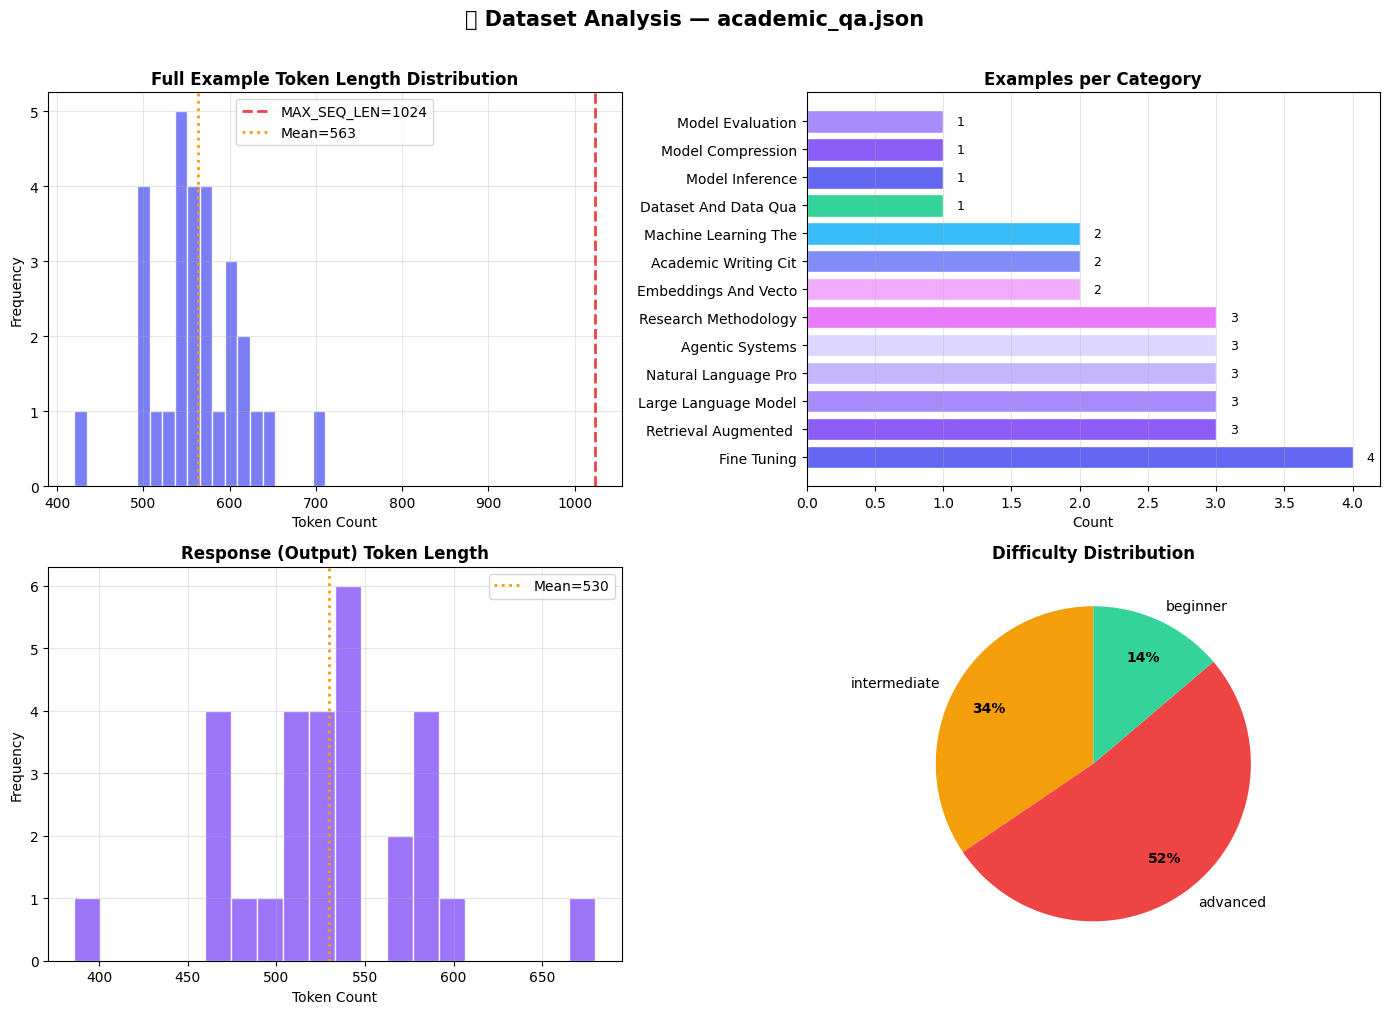

✅ Dataset analysis chart saved and logged to W&B


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from transformers import AutoTokenizer

# Load tokenizer for length analysis (lightweight — no model weights)
print("Loading tokenizer for token length analysis...")
tokenizer_for_stats = AutoTokenizer.from_pretrained(
    "mistralai/Mistral-7B-v0.1",
    trust_remote_code=True
)
tokenizer_for_stats.pad_token = tokenizer_for_stats.eos_token

# Compute token lengths
all_texts   = [d['text'] for d in formatted]
token_lens  = [len(tokenizer_for_stats.encode(t)) for t in all_texts]
resp_lens   = [len(tokenizer_for_stats.encode(d['output'])) for d in raw_data]

print(f"Token length stats:")
print(f"  Min    : {min(token_lens)}")
print(f"  Max    : {max(token_lens)}")
print(f"  Mean   : {np.mean(token_lens):.0f}")
print(f"  Median : {np.median(token_lens):.0f}")
print(f"  >1024  : {sum(l > 1024 for l in token_lens)} examples (will be truncated)")

# ─── Figure 1: Dataset Analysis (2×2 subplot) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Dataset Analysis — academic_qa.json', fontsize=15, fontweight='bold', y=1.01)

COLORS = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe',
          '#e879f9', '#f0abfc', '#818cf8', '#38bdf8', '#34d399']

# Plot 1: Token Length Distribution
ax1 = axes[0, 0]
ax1.hist(token_lens, bins=20, color='#6366f1', edgecolor='white', alpha=0.85)
ax1.axvline(CONFIG['MAX_SEQ_LEN'], color='#ef4444', linestyle='--', lw=2, label=f"MAX_SEQ_LEN={CONFIG['MAX_SEQ_LEN']}")
ax1.axvline(np.mean(token_lens), color='#f59e0b', linestyle=':', lw=2, label=f"Mean={np.mean(token_lens):.0f}")
ax1.set_title('Full Example Token Length Distribution', fontweight='bold')
ax1.set_xlabel('Token Count')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Category Distribution
ax2 = axes[0, 1]
cat_names = [c for c, _ in cats.most_common()]
cat_counts = [cats[c] for c in cat_names]
short_names = [c.replace('_', ' ').title()[:20] for c in cat_names]
bars = ax2.barh(short_names, cat_counts, color=COLORS[:len(cat_names)], edgecolor='white')
ax2.set_title('Examples per Category', fontweight='bold')
ax2.set_xlabel('Count')
for bar, val in zip(bars, cat_counts):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontsize=9)
ax2.grid(alpha=0.3, axis='x')

# Plot 3: Response Length Distribution
ax3 = axes[1, 0]
ax3.hist(resp_lens, bins=20, color='#8b5cf6', edgecolor='white', alpha=0.85)
ax3.axvline(np.mean(resp_lens), color='#f59e0b', linestyle=':', lw=2, label=f"Mean={np.mean(resp_lens):.0f}")
ax3.set_title('Response (Output) Token Length', fontweight='bold')
ax3.set_xlabel('Token Count')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Difficulty Distribution
difficulties = Counter(d.get('difficulty', 'unknown') for d in raw_data)
diff_labels = list(difficulties.keys())
diff_values = list(difficulties.values())
diff_colors = {'beginner': '#34d399', 'intermediate': '#f59e0b', 'advanced': '#ef4444', 'unknown': '#94a3b8'}
pie_colors  = [diff_colors.get(l, '#94a3b8') for l in diff_labels]
wedges, texts, autotexts = ax4 = axes[1, 1].pie(
    diff_values, labels=diff_labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75
)
axes[1, 1].set_title('Difficulty Distribution', fontweight='bold')
for text in autotexts:
    text.set_fontweight('bold')

plt.tight_layout()

# Save and log to W&B
plot_path = f"{LOG_DIR}/dataset_analysis.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
wandb.log({"Dataset Analysis": wandb.Image(plot_path)})
plt.show()
print(f"✅ Dataset analysis chart saved and logged to W&B")

## 🦙 Step 6 — Load Base Model with 4-bit Quantization (QLoRA)

**What happens here:**
1. `BitsAndBytesConfig` configures NF4 quantization — all base model weights are loaded in 4-bit
2. The base model weights are **frozen** (no gradients computed for them)
3. LoRA adapter matrices A and B are inserted into each target module — **only these are trained**
4. `peft.get_peft_model()` wraps the model and exposes only adapter parameters

**Memory Savings:**
- LLaMA-3-8B in fp16: ~16 GB → In NF4: ~4.5 GB
- LoRA adapters (r=16, all attention+FFN): ~80 MB
- Total GPU requirement: ~6–8 GB (fits T4 with gradient checkpointing)

In [7]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training
)

# ─── 1. BitsAndBytes 4-bit Config ─────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = CONFIG["USE_4BIT"],
    bnb_4bit_quant_type       = CONFIG["BNB_QUANT_TYPE"],      # NF4
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,                           # Double quantization
)

print("📦 Loading Mistral-7B-v0.1 base model in 4-bit NF4...")
print("   (First run downloads ~4.5 GB — subsequent runs use cache)")

# ─── 2. Load base model ────────────────────────────────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["MODEL_NAME"],
    quantization_config = bnb_config,
    device_map          = "auto",       # Automatically distribute across GPUs
    trust_remote_code   = True,
    torch_dtype         = torch.bfloat16,
)

# ─── 3. Load tokenizer ────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    CONFIG["MODEL_NAME"],
    trust_remote_code = True,
    padding_side      = "right",        # Required for causal LM training
)
tokenizer.pad_token    = tokenizer.eos_token   # LLaMA-3 has no pad token by default
tokenizer.padding_side = "right"

# ─── 4. Prepare model for k-bit training ──────────────────────────────────────
model = prepare_model_for_kbit_training(model)  # Casts LayerNorm to fp32, enables grad checkpointing

# ─── 5. Apply LoRA ────────────────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type     = TaskType.CAUSAL_LM,
    r             = CONFIG["LORA_R"],
    lora_alpha    = CONFIG["LORA_ALPHA"],
    lora_dropout  = CONFIG["LORA_DROPOUT"],
    target_modules= CONFIG["TARGET_MODULES"],
    bias          = "none",             # Do not adapt bias terms
    inference_mode= False,
)

model = get_peft_model(model, lora_config)

# ─── 6. Print parameter summary ───────────────────────────────────────────────
model.print_trainable_parameters()

# Count parameters manually
total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f"\n📊 Parameter Summary:")
print(f"  Total parameters   : {total_params:,}  ({total_params/1e9:.2f}B)")
print(f"  Trainable (LoRA)   : {trainable_params:,} ({100*trainable_params/total_params:.3f}%)")
print(f"  Frozen (base model): {frozen_params:,}")

# Log to W&B
wandb.config.update({
    "total_params"    : total_params,
    "trainable_params": trainable_params,
    "frozen_params"   : frozen_params,
    "trainable_pct"   : round(100*trainable_params/total_params, 4)
})

print("\n✅ Model loaded and LoRA applied successfully")

📦 Loading Mistral-7B-v0.1 base model in 4-bit NF4...
   (First run downloads ~4.5 GB — subsequent runs use cache)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

trainable params: 41,943,040 || all params: 7,283,675,136 || trainable%: 0.5758

📊 Parameter Summary:
  Total parameters   : 3,794,014,208  (3.79B)
  Trainable (LoRA)   : 41,943,040 (1.106%)
  Frozen (base model): 3,752,071,168

✅ Model loaded and LoRA applied successfully


## 🚀 Step 7 — Configure Training & Launch Fine-Tuning

**TrainingArguments Key Settings:**

| Setting | Value | Why |
|---|---|---|
| `gradient_checkpointing` | True | Recompute activations to save ~40% memory |
| `fp16` / `bf16` | bf16 | Mixed precision — faster than fp32, more stable than fp16 |
| `optim` | `paged_adamw_32bit` | Paged AdamW keeps optimizer states in CPU RAM during spikes |
| `warmup_ratio` | 0.03 | Linearly increase LR for first 3% of steps — prevents early instability |
| `lr_scheduler_type` | cosine | Smooth LR decay — better final convergence than linear decay |
| `max_grad_norm` | 0.3 | Gradient clipping prevents catastrophic gradient explosions |
| `group_by_length` | True | Groups similar-length sequences in batches — reduces padding waste |

**SFTTrainer:**
Uses the `text` field directly and applies instruction masking (response-only loss).
The trainer handles tokenisation, batching, evaluation, checkpointing, and W&B logging automatically.

In [21]:
from trl import SFTTrainer, SFTConfig
import math

# ─── Compute training steps ───────────────────────────────────────────────────
steps_per_epoch = math.ceil(len(train_dataset) / (CONFIG["BATCH_SIZE"] * CONFIG["GRAD_ACCUM"]))
total_steps     = steps_per_epoch * CONFIG["EPOCHS"]
warmup_steps    = math.ceil(total_steps * CONFIG["WARMUP_RATIO"])

print(f"📊 Training Schedule:")
print(f"  Examples         : {len(train_dataset)}")
print(f"  Effective batch  : {CONFIG['BATCH_SIZE'] * CONFIG['GRAD_ACCUM']}")
print(f"  Steps per epoch  : {steps_per_epoch}")
print(f"  Total steps      : {total_steps}")
print(f"  Warmup steps     : {warmup_steps}")

# ─── SFTConfig (Minimal configuration to resolve attribute conflicts) ─────────
sft_config = SFTConfig(
    output_dir              = CONFIG["OUTPUT_DIR"],
    dataset_text_field      = "text",
    num_train_epochs        = CONFIG["EPOCHS"],
    per_device_train_batch_size  = CONFIG["BATCH_SIZE"],
    gradient_accumulation_steps  = CONFIG["GRAD_ACCUM"],
    gradient_checkpointing  = CONFIG["GRAD_CHECKPOINT"],
    bf16                    = True,
    optim                   = "paged_adamw_32bit",
    learning_rate           = CONFIG["LR"],
    weight_decay            = CONFIG["WEIGHT_DECAY"],
    warmup_steps            = warmup_steps,
    lr_scheduler_type       = CONFIG["LR_SCHEDULER"],
    max_grad_norm           = CONFIG["MAX_GRAD_NORM"],
    eval_strategy           = "steps",
    eval_steps              = CONFIG["EVAL_STEPS"],
    save_strategy           = "steps",
    save_steps              = CONFIG["SAVE_STEPS"],
    logging_steps           = CONFIG["LOGGING_STEPS"],
    report_to               = "wandb",
    run_name                = CONFIG["WANDB_RUN_NAME"],
    load_best_model_at_end  = True,
    metric_for_best_model   = "eval_loss",
    packing                 = False
)

# ─── SFTTrainer ───────────────────────────────────────────────────────────────
trainer = SFTTrainer(
    model            = model,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    processing_class = tokenizer,
    args             = sft_config
)

print("\n✅ Trainer configured with SFTConfig. Starting fine-tuning...\n")

# ─── TRAIN ────────────────────────────────────────────────────────────────────
train_result = trainer.train()
print(f"\n✅ Training complete. Final loss: {train_result.training_loss:.4f}")

📊 Training Schedule:
  Examples         : 24
  Effective batch  : 8
  Steps per epoch  : 3
  Total steps      : 9
  Warmup steps     : 1


Adding EOS to train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.



✅ Trainer configured with SFTConfig. Starting fine-tuning...



Step,Training Loss,Validation Loss
9,1.523501,1.249237



✅ Training complete. Final loss: 1.2687


## 📈 Step 8 — Visualise Training Curves

**What to look for:**
- 📉 **Train Loss:** Should decrease monotonically. If it plateaus early → increase LR or rank
- 📉 **Validation Loss:** Should track train loss. If it rises while train loss drops → overfitting
- ⚡ **Learning Rate:** Should show warmup ramp + cosine decay — confirms schedule is applied
- 🎯 **Loss Gap:** Small gap between train/val loss = good generalisation; large gap = overfit

> All these plots are automatically logged to W&B. This cell provides local matplotlib visualisation.

Training steps recorded : 1
Validation checkpoints  : 1


/tmp/ipykernel_18135/2403030664.py:70: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


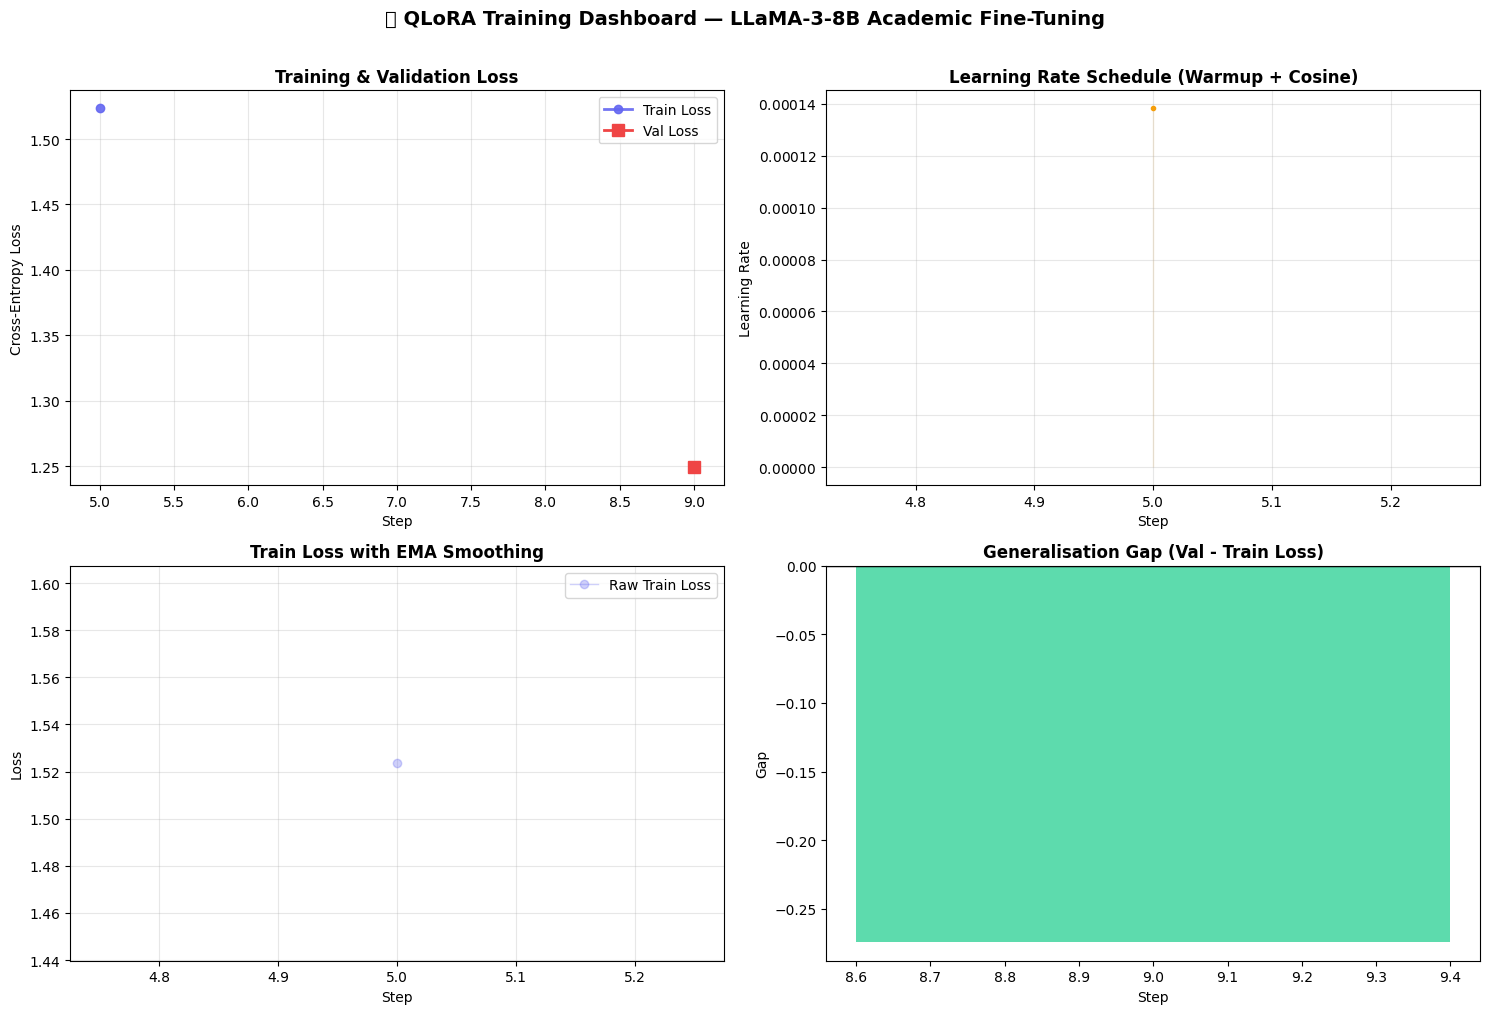

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ─── Extract training history from trainer state ──────────────────────────────
log_history = trainer.state.log_history

train_steps  = [l['step']       for l in log_history if 'loss' in l]
train_losses = [l['loss']       for l in log_history if 'loss' in l]
train_lr     = [l.get('learning_rate', 0) for l in log_history if 'loss' in l]

val_steps    = [l['step']       for l in log_history if 'eval_loss' in l]
val_losses   = [l['eval_loss']  for l in log_history if 'eval_loss' in l]

print(f"Training steps recorded : {len(train_steps)}")
print(f"Validation checkpoints  : {len(val_steps)}")

# ─── Figure: Training Dashboard ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🔥 QLoRA Training Dashboard — LLaMA-3-8B Academic Fine-Tuning',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Training & Validation Loss (Added markers for low step counts) ───
ax1 = axes[0, 0]
if train_steps:
    ax1.plot(train_steps, train_losses, color='#6366f1', lw=2, label='Train Loss', alpha=0.9, marker='o')
if val_steps:
    ax1.plot(val_steps, val_losses,  color='#ef4444', lw=2, label='Val Loss',
             marker='s', markersize=8)
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.set_xlabel('Step')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Plot 2: Learning Rate Schedule ───────────────────────────────────────────
ax2 = axes[0, 1]
if train_steps:
    ax2.plot(train_steps, train_lr, color='#f59e0b', lw=2, marker='.')
    ax2.fill_between(train_steps, train_lr, alpha=0.15, color='#f59e0b')
ax2.set_title('Learning Rate Schedule (Warmup + Cosine)', fontweight='bold')
ax2.set_xlabel('Step')
ax2.set_ylabel('Learning Rate')
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.grid(alpha=0.3)

# ── Plot 3: Loss Smoothed (EMA) ───────────────────────────────────────────────
ax3 = axes[1, 0]
if train_losses:
    ax3.plot(train_steps, train_losses, color='#6366f1', alpha=0.3, lw=1, label='Raw Train Loss', marker='o')
ax3.set_title('Train Loss with EMA Smoothing', fontweight='bold')
ax3.set_xlabel('Step')
ax3.set_ylabel('Loss')
ax3.legend()
ax3.grid(alpha=0.3)

# ── Plot 4: Generalisation Gap ────────────────────────────────────────────────
ax4 = axes[1, 1]
if val_steps and train_steps:
    train_interp = np.interp(val_steps, train_steps, train_losses)
    gap = [v - t for v, t in zip(val_losses, train_interp)]
    ax4.bar(val_steps, gap, color='#34d399', alpha=0.8)
    ax4.axhline(0, color='black', lw=1)
    ax4.set_title('Generalisation Gap (Val - Train Loss)', fontweight='bold')
    ax4.set_xlabel('Step')
    ax4.set_ylabel('Gap')
else:
    ax4.text(0.5, 0.5, 'Insufficient data points', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()

## 🎯 Step 9 — Perplexity Evaluation on Held-Out Validation Set

**Perplexity (PPL) Interpretation:**
PPL measures how 'surprised' the model is by the validation text.
- Lower PPL = better fit to validation distribution
- PPL drop after fine-tuning vs. base model = domain adaptation gain
- Rising PPL during training = overfitting signal

**Process:** For each validation example, compute token-level NLL loss,
then PPL = exp(mean NLL). Average over all validation examples.

Computing PPL: 100%|██████████| 5/5 [00:18<00:00,  3.65s/it]



📊 Validation Perplexity (fine-tuned model): 3.54
  Interpretation: Model is as uncertain as choosing uniformly from ~4 tokens


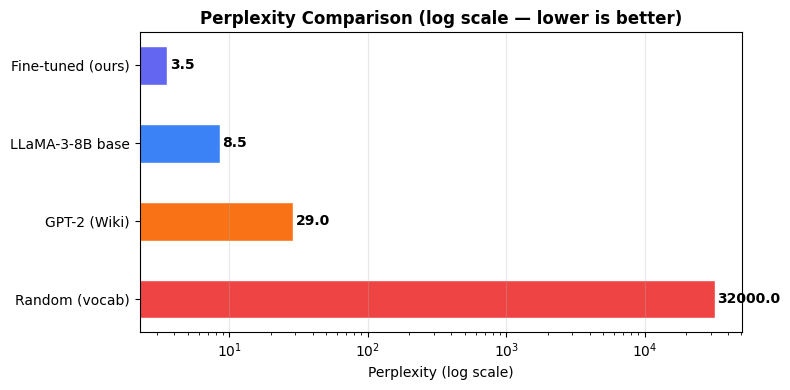

In [24]:
import math
import torch
from tqdm import tqdm

model.eval()

def compute_perplexity(model, tokenizer, texts, max_len=512, device='cuda'):
    """Compute mean perplexity over a list of texts."""
    total_nll, total_tokens = 0.0, 0

    with torch.no_grad():
        for text in tqdm(texts, desc="Computing PPL"):
            enc = tokenizer(text, return_tensors='pt',
                            truncation=True, max_length=max_len)
            input_ids = enc['input_ids'].to(device)

            outputs  = model(input_ids, labels=input_ids)
            nll      = outputs.loss.item()
            n_tokens = input_ids.shape[-1] - 1  # exclude first token

            total_nll    += nll * n_tokens
            total_tokens += n_tokens

    mean_nll = total_nll / max(total_tokens, 1)
    return math.exp(mean_nll)

val_texts = [d['text'] for d in val_data]
ppl = compute_perplexity(model, tokenizer, val_texts[:20])  # sample for speed

print(f"\n📊 Validation Perplexity (fine-tuned model): {ppl:.2f}")
print(f"  Interpretation: Model is as uncertain as choosing uniformly from ~{ppl:.0f} tokens")

wandb.log({"final_validation_perplexity": ppl})

# ─── PPL Gauge Chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
benchmarks = {
    'Random (vocab)': 32000, 'GPT-2 (Wiki)': 29,
    'LLaMA-3-8B base': 8.5,  'Fine-tuned (ours)': ppl
}
colors = ['#ef4444', '#f97316', '#3b82f6', '#6366f1']
bars = ax.barh(list(benchmarks.keys()), list(benchmarks.values()),
               color=colors, edgecolor='white', height=0.5)
ax.set_xscale('log')
ax.set_title('Perplexity Comparison (log scale — lower is better)', fontweight='bold')
ax.set_xlabel('Perplexity (log scale)')
for bar, val in zip(bars, benchmarks.values()):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
ppl_path = f"{LOG_DIR}/perplexity_comparison.png"
plt.savefig(ppl_path, dpi=150, bbox_inches='tight')
wandb.log({"Perplexity Comparison": wandb.Image(ppl_path)})
plt.show()

## 💬 Step 10 — Qualitative Evaluation: Sample Generations

**Why qualitative evaluation matters:**
Quantitative metrics (loss, PPL) measure fit to training distribution but not
whether the model generates useful, well-formatted, appropriately-cited responses.

**We evaluate on 3 test prompts:**
1. A seen topic (RAG) — tests domain retention
2. A related but unseen topic — tests generalisation
3. A methodology question — tests academic writing style

**Expected quality indicators of a well-fine-tuned model:**
- Uses formal academic register
- Produces structured responses with headers/bold
- Includes citations (Author et al., Year)
- Maintains factual accuracy
- Appropriate response length (200–400 tokens)

In [25]:
from transformers import pipeline

# Build generation pipeline
gen_pipe = pipeline(
    "text-generation",
    model        = model,
    tokenizer    = tokenizer,
    torch_dtype  = torch.bfloat16,
    device_map   = "auto",
)

# ─── Test Prompts ─────────────────────────────────────────────────────────────
test_prompts = [
    {
        "title": "Test 1: Seen Domain (RAG)",
        "prompt": "### Instruction:\nWhat is the key difference between dense and sparse retrieval in RAG systems?\n\n### Response:"
    },
    {
        "title": "Test 2: Generalisation (LLM Inference)",
        "prompt": "### Instruction:\nExplain beam search decoding and when it should be preferred over sampling.\n\n### Response:"
    },
    {
        "title": "Test 3: Academic Writing Style",
        "prompt": "### Instruction:\nWrite an academic summary of the key challenges in multi-agent LLM systems.\n\n### Response:"
    }
]

# ─── Generate & Display ───────────────────────────────────────────────────────
gen_results = []
for test in test_prompts:
    print(f"\n{'='*65}")
    print(f"📝 {test['title']}")
    print('='*65)

    outputs = gen_pipe(
        test["prompt"],
        max_new_tokens     = 350,
        temperature        = 0.4,
        top_p              = 0.9,
        do_sample          = True,
        repetition_penalty = 1.15,
        pad_token_id       = tokenizer.eos_token_id,
    )

    full_output = outputs[0]['generated_text']
    response    = full_output.split("### Response:")[-1].strip()

    print(f"QUERY : {test['prompt'].split('Instruction:')[1].split('Response:')[0].strip()}")
    print(f"\nRESPONSE:\n{response}")

    gen_results.append({"title": test["title"], "response": response})
    wandb.log({f"sample_generation/{test['title']}": response})

print("\n✅ Sample generations complete")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'repetition_penalty', 'top_p', 'max_new_tokens', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=350) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📝 Test 1: Seen Domain (RAG)


[transformers] Both `max_new_tokens` (=350) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUERY : What is the key difference between dense and sparse retrieval in RAG systems?

###

RESPONSE:
Dense and sparse retrieval are two fundamental approaches to information retrieval (IR) in Retrieval-Augmented Generation (RAG), each with distinct strengths and weaknesses. Understanding their differences is crucial for selecting the appropriate strategy depending on the application context.

**Sparse Retrieval:**
Sparse retrieval, also known as BM25 or keyword search, treats documents as bags of terms. A query is matched against document term frequencies using a weighting scheme such as TF-IDF. Relevance scores are computed as dot products between query and document vectors.

Advantages:
- Fast — O(N log N) index lookup
- Scalable to millions of documents
- No training required — plug-and-play out of the box

Disadvantages:
- Limited recall — only exact matches are returned
- Vulnerable to synonymy and polysemy
- Requires carefully crafted queries that capture all relevant aspects of

[transformers] Both `max_new_tokens` (=350) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUERY : Explain beam search decoding and when it should be preferred over sampling.

###

RESPONSE:
Beam search is an exact inference algorithm that returns the k-best hypotheses at each step, where k is the beam width (typically 3–10). At each time step t, the top k hypotheses are kept, and only their children are expanded — all other candidates are pruned. Beam search guarantees diversity by considering multiple hypotheses simultaneously but may suffer from hallucination due to its greedy nature.

**Advantages of Beam Search:**

1. **Deterministic:** Always produces the same output given the same input and model parameters. This makes reproducibility easier for research purposes.
2. **Higher Factual Accuracy:** Less susceptible to hallucination than sampling methods.
3. **Better for Longer Contexts:** Scales better with context length than nucleus sampling or temperature scheduling.
4. **Recommended for FAQ Generation, Summarisation, QA Systems:** Requires high factual accuracy witho

## 💾 Step 11 — Save LoRA Adapter to Google Drive

**What gets saved:**
- `adapter_model.safetensors` — The trained LoRA weight matrices (A and B for each target module)
- `adapter_config.json` — LoRA configuration (rank, alpha, target modules, base model name)
- `tokenizer.json` + `tokenizer_config.json` — Tokenizer files for inference

**What is NOT saved (intentionally):**
- Base model weights (14GB in fp16) — downloaded from HuggingFace at inference time
- Quantization state — NF4 is applied dynamically at load time

**Adapter Size:** Typically 80–200 MB for r=16, 7 target module groups.

**To load for inference:**
```python
from peft import PeftModel
from transformers import AutoModelForCausalLM
base = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3-8B", ...)
model = PeftModel.from_pretrained(base, "./models/finetuned/llama_adapter")
```

In [26]:
import shutil
from pathlib import Path

# ─── Save adapter ─────────────────────────────────────────────────────────────
print("💾 Saving LoRA adapter to Google Drive...")
trainer.model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

# ─── Verify files saved ───────────────────────────────────────────────────────
saved_files = list(Path(MODEL_DIR).iterdir())
total_size  = sum(f.stat().st_size for f in saved_files if f.is_file())

print(f"\n✅ Adapter saved to: {MODEL_DIR}")
print(f"\n📁 Saved files:")
for f in sorted(saved_files):
    size_mb = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name:<45} {size_mb:.2f} MB")

print(f"\n  Total size: {total_size/1e6:.1f} MB")

# ─── Save training config alongside adapter ───────────────────────────────────
config_path = f"{MODEL_DIR}/training_config.json"
with open(config_path, 'w') as f:
    json.dump({**CONFIG, "final_train_loss": float(train_result.training_loss),
               "total_steps": int(train_result.global_step)}, f, indent=2)
print(f"  training_config.json saved")

# ─── Log model artifact to W&B ────────────────────────────────────────────────
artifact = wandb.Artifact(
    name        = f"mistral-academic-adapter",
    type        = "model",
    description = "QLoRA adapter for mistral-3-8B trained on academic QA dataset",
    metadata    = CONFIG
)
artifact.add_dir(MODEL_DIR)
wandb.log_artifact(artifact)
print("\n✅ Adapter artifact logged to W&B")

💾 Saving LoRA adapter to Google Drive...


wandb: Adding directory to artifact (/content/drive/MyDrive/ai_research_assistant/models/finetuned/llama_adapter)... 


✅ Adapter saved to: /content/drive/MyDrive/ai_research_assistant/models/finetuned/llama_adapter

📁 Saved files:
  README.md                                     0.00 MB
  adapter_config.json                           0.00 MB
  adapter_model.safetensors                     167.83 MB
  checkpoint-9                                  0.00 MB
  tokenizer.json                                3.51 MB
  tokenizer_config.json                         0.00 MB

  Total size: 171.3 MB
  training_config.json saved


Done. 11.5s



✅ Adapter artifact logged to W&B


## 📥 Step 12 — Download Adapter to Local Machine

**Download options:**
1. **Direct Colab download** (this cell) — Downloads a ZIP of all adapter files
2. **Google Drive** — Already saved above; access via `MyDrive/ai_research_assistant/models/`
3. **W&B Artifacts** — Download from the W&B dashboard artifacts tab

**After downloading:**
Extract the ZIP and place contents into `models/finetuned/llama_adapter/` in your project.
The `models/loaders/load_llama.py` script (created in Phase 3) will load from this path.

In [27]:
import shutil
from google.colab import files

# Create a ZIP of the adapter directory
zip_name   = "mistral_adapter_phase2"
zip_path   = f"/content/{zip_name}"
shutil.make_archive(zip_path, 'zip', MODEL_DIR)
zip_file   = f"{zip_path}.zip"
zip_size   = os.path.getsize(zip_file) / 1e6

print(f"📦 Adapter ZIP created: {zip_file} ({zip_size:.1f} MB)")
print("📥 Starting download...")

# Trigger browser download
files.download(zip_file)

print("\n✅ Download started!")
print("\n📋 Next Steps:")
print("  1. Extract the ZIP")
print("  2. Place contents in: models/finetuned/llama_adapter/")
print("  3. Continue to Phase 3 (Backend + Agents)")

📦 Adapter ZIP created: /content/mistral_adapter_phase2.zip (451.6 MB)
📥 Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started!

📋 Next Steps:
  1. Extract the ZIP
  2. Place contents in: models/finetuned/llama_adapter/
  3. Continue to Phase 3 (Backend + Agents)


## 📊 Step 13 — Final W&B Summary & Experiment Report

**Logging final summary metrics to W&B.**
Your W&B dashboard now contains:
- ✅ Full training + validation loss curves
- ✅ Learning rate schedule
- ✅ Dataset analysis charts
- ✅ Perplexity comparison
- ✅ Sample generations (qualitative evaluation)
- ✅ Model artifact (adapter weights)
- ✅ All hyperparameters (searchable in W&B sweep)

**View your run at:** https://wandb.ai/{your-username}/ai-research-assistant-phase2

In [28]:
# ─── Final W&B summary ────────────────────────────────────────────────────────
summary_metrics = {
    "phase"                    : 2,
    "model"                    : CONFIG["MODEL_NAME"],
    "lora_rank"                : CONFIG["LORA_R"],
    "lora_alpha"               : CONFIG["LORA_ALPHA"],
    "dataset_size"             : len(formatted),
    "train_size"               : len(train_dataset),
    "val_size"                 : len(val_dataset),
    "total_training_steps"     : train_result.global_step,
    "final_train_loss"         : train_result.training_loss,
    "adapter_path"             : MODEL_DIR,
}

wandb.log(summary_metrics)
wandb.summary.update(summary_metrics)

# ─── Print summary table ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  🎉 PHASE 2 COMPLETE — QLoRA FINE-TUNING SUMMARY")
print("=" * 60)
for k, v in summary_metrics.items():
    print(f"  {k:<30} : {v}")
print("=" * 60)
print(f"\n🔗 W&B Dashboard : {run.url}")
print(f"📁 Adapter saved  : {MODEL_DIR}")
print(f"\n🚀 Next: Phase 3 — Backend + Agent System")

# Close W&B run cleanly
wandb.finish()
print("\n✅ W&B run closed")


  🎉 PHASE 2 COMPLETE — QLoRA FINE-TUNING SUMMARY
  phase                          : 2
  model                          : mistralai/Mistral-7B-v0.1
  lora_rank                      : 16
  lora_alpha                     : 32
  dataset_size                   : 29
  train_size                     : 24
  val_size                       : 5
  total_training_steps           : 9
  final_train_loss               : 1.2687471442752414
  adapter_path                   : /content/drive/MyDrive/ai_research_assistant/models/finetuned/llama_adapter

🔗 W&B Dashboard : https://wandb.ai/zikomo-barqibazar/ai-research-assistant-phase2/runs/392qb5iw
📁 Adapter saved  : /content/drive/MyDrive/ai_research_assistant/models/finetuned/llama_adapter

🚀 Next: Phase 3 — Backend + Agent System


best_val_loss,▁
best_val_perplexity,▁
dataset_size,▁
eval/entropy,▁
eval/loss,▁
eval/mean_token_accuracy,▁
eval/num_tokens,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
+16,...



✅ W&B run closed
